# Практична робота 5. Розпізнавання обличчя та об'єктів з web-камери за допомогою попередньо навчених моделей, SSD, YOLO та OpenCV

Основні матеріали для цього курсу створено за допомогою блокнотів Jupyter. Це дозволяє вставити код виконання безпосередньо в матеріал лабораторних робіт та використовувати його для демонстрації алгоритмів Щоб запускати та редагувати код, збережіть копію цього ноутбука собі (File->Save a copy in Drive...). Свою копію ви зможете змінювати та запускати

Цей розділ завантажує деякі необхідні бібліотеки, що використовуються в проекті.
Ми будемо використовувати бібліотеку для завдань комп'ютерного зору OpenCV

In [ ]:
# набір зручних функцій для полегшення основних функцій обробки зображень, таких як трансформація,
# обертання, зміна розміру, скелетування, відображення зображень Matplotlib, сортування контурів, виявлення країв
import imutils
# це бібліотека роботи з масивами, що використовується для лінійної алгебри, перетворення Фур'є та можливостей випадкових чисел
import numpy as np
# це бібліотека для завдань комп'ютерного зору OpenCV
import cv2
# для відображення зображень
from google.colab.patches import cv2_imshow
# щоб ввести на сторінку деякий JavaScript
from IPython.display import display, Javascript
# щоб оцініть вираз Javascript з Python
from google.colab.output import eval_js
# функції для кодування двійкових даних у символи ASCII та декодування назад у двійкові дані
from base64 import b64decode

CLASSES = ["background", "aeroplane", "bicycle", "bird", "boat",
     "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
     "dog", "horse", "motorbike", "person", "pottedplant", "sheep",
     "sofa", "train", "tvmonitor"]
COLORS = np.random.uniform(0, 255, size=(len(CLASSES), 3))

Детектор глибокого навчання OpenCV заснований на системі Single Shot Detector (SSD) з базовою мережею ResNet. Мережа визначається та навчається за допомогою системи [Caffe Deep Learning framework](https://caffe.berkeleyvision.org/)

Зазвичай модель Caffe кодується у 3 файли

* Файл prototxt: текстовий файл Caffe JSON, який містить визначення моделі (розгортання) (тобто шари, очікувані вхідні дані, …..)
* Попередньо підготовлена ​​модель Caffe: ваги нейронної мережі.
* Мітки: текстовий файл із мітками, які модель може класифікувати

Завантажте попередньо навчену модель розпізнавання обличчя, що складається з двох файлів:

- визначення мережі (deploy.prototxt)
- сінаптичні ваги, що було отримано при навчанні (res10_300x300_ssd_iter_140000.caffemodel)

In [ ]:
!wget -N https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!wget -N https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

Починаючи з OpenCV 3.1, у бібліотеці є модуль DNN, який реалізує пряму передачу (виведення) з глибокими мережами, попередньо навченими за допомогою деяких популярних фреймворків глибокого навчання, таких як TensorFlow та [Caffe Deep Learning framework](https://caffe.berkeleyvision.org/)

Підтримувані шари:

* AbsVal
* Accum
* AveragePooling
* BatchNormalization
* BNLL
* Concatenation
* Convolution (1d, 2d, including dilated convolution, 3d)
* Crop
* CropAndResize (RCNN-specific layer)
* Deconvolution, a.k.a. transposed convolution or full convolution
* DetectionOutput (SSD-specific layer)
* Dropout
* Eltwise (+, *, max)
* ELU
* Expand
* Flatten
* FullyConnected
* FlowWarp
* Gather
* Interpolation
* LRN
* LSTM
* MaxPooling
* MaxUnpooling
* Mish
* MVN
* NormalizeBBox (SSD-specific layer)
* Padding
* Permute
* Power
* PReLU (including ChannelPReLU with channel-specific slopes)
* PriorBox (SSD-specific layer)
* ReLU
* ReduceL1
* ReduceL2
* ReduceLogSum
* ReduceLogSumExp
* ReduceMax
* ReduceMean
* ReduceMin
* ReduceProd
* ReduceSum
* ReduceSumSquare
* Region (for DarkNet models)
* Reorg
* Resize
* RNN
* ROI Pooling (RCNN-specific layer)
* Scale
* Shift
* ShuffleChannel
* Sigmoid
* Slice
* Softmax
* Split
* Swish
* TanH

Ви також можете написати свій власний користувацький шар.

Модуль містить деяке прискорення SSE, AVX, AVX2 і NEON критичних для продуктивності рівнів, а також підтримку CUDA для більшості рівнів

Наданий API (для C++ і Python) дуже простий у використанні, просто завантажте мережу та запустіть її. Підтримується кілька входів/виходів

Завантажте попередньо навчену модель розпізнавання об'єктів, що складається з двох файлів з Google Disk:

*   визначення мережі (MobileNetSSD_deploy.prototxt)
*   сінаптичні ваги, що було отримано при навчанні (MobileNetSSD_deploy.caffemodel)



In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1IAWnZzMnIE33k9KYocv0685irjyJrfoM' -O MobileNetSSD_deploy.prototxt
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=117xjbhCnhkdkGpPHWFtwMv5wzgPv-jrd' -O MobileNetSSD_deploy.caffemodel

Вирішуємо дві задачі - виявлення обличь та виявлення об'єктів, тому різні фрагменти коду

Далі завантажте попередньо навчену модель мережі виявлення обличчя з диска

In [ ]:
print("[INFO] loading model...")
prototxt = 'deploy.prototxt'
model = 'res10_300x300_ssd_iter_140000.caffemodel'
net = cv2.dnn.readNetFromCaffe(prototxt, model)

Завантажте попередньо навчену модель мережі виявлення об'єктів з диска (надається в роботі)

In [ ]:
print("[INFO] loading model...")
prototxt = 'MobileNetSSD_deploy.prototxt'
model = 'MobileNetSSD_deploy.caffemodel'
net_obj = cv2.dnn.readNetFromCaffe(prototxt, model)

Запустіть веб-камеру

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // змінити розмір виводу відповідно до елемента відео
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // зачекати, поки буде натиснуто Capture
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename


Клацніть «Capture», щоб зробити фото за допомогою веб-камери

In [ ]:
image_file = take_photo()

Зчитування, зміна розміру та відображення зображення

In [ ]:
#image = cv2.imread(image_file, cv2.IMREAD_UNCHANGED)
image = cv2.imread(image_file)

# змінити зображення, щоб мати максимальну ширину 400 пікселів
image = imutils.resize(image, width=400)
(h, w) = image.shape[:2]
print(w,h)
cv2_imshow(image)

Використовуйте функцію [dnn.blobFromImage](https://www.pyimagesearch.com/2017/11/06/deep-learning-opencvs-blobfromimage-works/), щоб побудувати вхідний blob, змінивши розмір зображення до фіксованого 300x300 пікселів, а потім нормалізувавши його


In [ ]:
# змініть зображення для виявлення обличчя, щоб мати максимальну ширину 400 пікселів
image = imutils.resize(image, width=400)
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

In [ ]:
# змініть зображення для виявлення об'єктів
image = imutils.resize(image, width=400)
blob_obj = cv2.dnn.blobFromImage(image, 0.007843, (300, 300), (127.5, 127.5, 127.5), False)


Пропустити blob через нейронну мережу і отримати результат детектування і прогноз щодо виявлення обличь

In [ ]:
print("[INFO] computing face detections...")
net.setInput(blob)
detections = net.forward()


Пропустити blob через нейронну мережу і отримати результат детектування і прогноз щодо виявлення об'єктів

In [ ]:
print("[INFO] computing object detections...")
net_obj.setInput(blob_obj)
detections_obj = net_obj.forward()

Цикл за детектуванням та проведення навколо виявлених границь обличь

In [ ]:
for i in range(0, detections.shape[2]):

	# вилучити довіру (тобто ймовірність), пов’язану з передбаченням
	confidence = detections[0, 0, i, 2]

	# відфільтруйте слабкі виявлення, переконавшись, що `довіра` перевищує мінімальний поріг довіри
	if confidence > 0.5:
		# обчислення (x, y) - координати обмежувального вікна для об'єкта
		box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
		(startX, startY, endX, endY) = box.astype("int")
		# намалюємо обмежувальну рамку обличчя разом із відповідною ймовірністю
		idx = int(detections[0, 0, i, 1])
		text = "{:.2f}%".format(confidence * 100)
		y = startY - 10 if startY - 10 > 10 else startY + 10
		cv2.rectangle(image, (startX, startY), (endX, endY), COLORS[idx], 2)
		cv2.putText(image, text, (startX, y),
			cv2.FONT_HERSHEY_SIMPLEX, 0.45, COLORS[idx], 2)

Цикл за детектуванням та проведення навколо виявлених границь об'єктів

In [ ]:
for i in range(0, detections_obj.shape[2]):

	# вилучити довіру (тобто ймовірність), пов’язану з передбаченням
	confidence = detections_obj[0, 0, i, 2]

	# відфільтруйте слабкі виявлення, переконавшись, що `довіра` перевищує мінімальний поріг довіри
	if confidence > 0.5:
		# обчислення (x, y) - координати обмежувального вікна для об'єкта
		box = detections_obj[0, 0, i, 3:7] * np.array([w, h, w, h])
		(startX, startY, endX, endY) = box.astype("int")
		# намалюємо обмежувальну рамку обличчя разом із відповідною ймовірністю
		idx = int(detections_obj[0, 0, i, 1])
		text = '{}: {:.2f}%'.format(CLASSES[idx], confidence * 100)
		y = startY - 10 if startY - 10 > 10 else startY + 10
		cv2.rectangle(image, (startX, startY), (endX, endY), COLORS[idx], 2)
		cv2.putText(image, text, (startX, y),
			cv2.FONT_HERSHEY_SIMPLEX, 0.45, COLORS[idx], 2)

Покажемо отримані зображення

In [ ]:
cv2_imshow(image)

## Розпізнавання об'єктів з web-камери за допомогою попередньо навченої моделі YOLO та OpenCV

In [ ]:
# встановлюємо пакет для YOLO
!pip install opencv-python ultralytics

In [ ]:
import cv2
import torch

from ultralytics import YOLO

YOLO12 представляє архітектуру, орієнтовану на увагу, яка відрізняється від традиційних підходів на основі CNN, що використовувалися в попередніх моделях YOLO, але при цьому зберігає швидкість виведення в реальному часі, необхідну для багатьох програм. Ця модель досягає найвищої точності виявлення об'єктів завдяки новим методологічним інноваціям у механізмах уваги та загальної архітектури мережі, зберігаючи при цьому продуктивність у реальному часі.

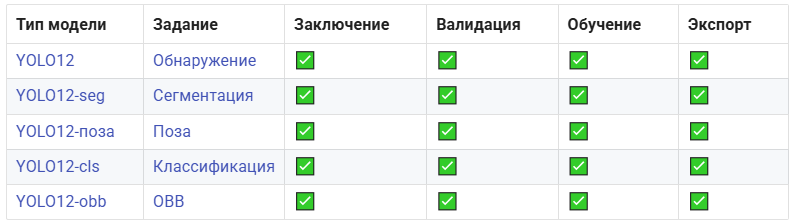

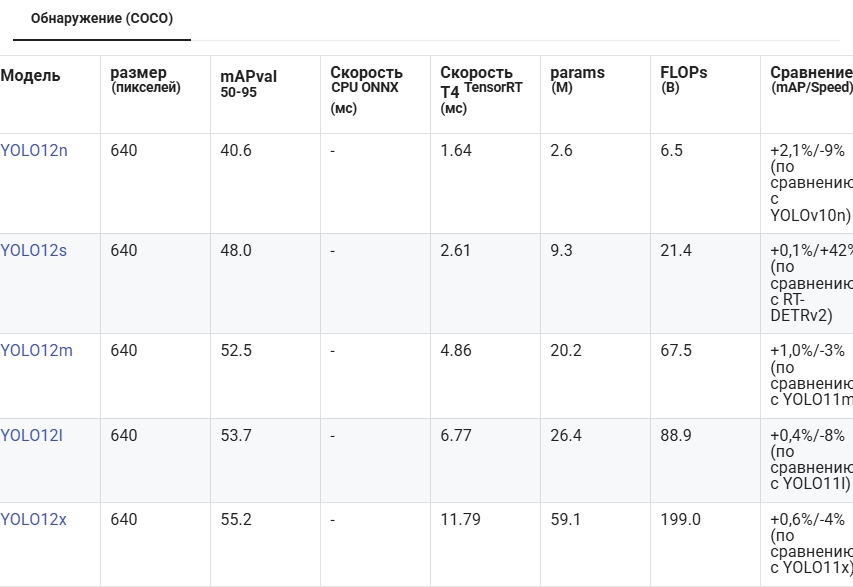

In [ ]:
# якщо є підтримка GPU та CUDA
device = 'cuda' if torch.cuda.is_available() else "cpu"
# завантажуємо попередньо навчену модель YOLO для розпізнавання обєктів на базі COCO

model = YOLO("yolo12n.pt")

Запустіть веб-камеру

In [ ]:
# функція для того, щоб взяти зображення з камери
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // змінити розмір виводу відповідно до елемента відео
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // зачекати, поки буде натиснуто Capture
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename


Клацніть «Capture», щоб зробити фото за допомогою веб-камери

In [ ]:
image_file = take_photo()

Ultralytics YOLO моделі повертають або список Python Results об'єктів, або економію пам'яті Python генератор Results, коли stream=True передається моделі під час виведення

In [ ]:
# виконуємо передбачення із моделлю YOLO на зображенні з камери
results = model.predict(image_file, save=True, conf=0.5)

In [ ]:
image = cv2.imread("runs/detect/predict/photo.jpg")

cv2_imshow(image)

In [ ]:
results

In [ ]:
# виконуємо передбачення із моделлю YOLO на зображенні з мережі
img_path = r"https://kharkovblog.info/edit/uploads/page/1324/5f3f6bb4a6160.jpg"

model.predict(img_path, save=True, conf=0.3)

In [ ]:
image = cv2.imread("runs/detect/predict/5f3f6bb4a6160.jpg")

cv2_imshow(image)

In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1xkWE6CDhmtRplwuRR3wB94h2u_ud6j1p' -O video.mp4

In [ ]:
# виконуємо передбачення із моделлю YOLO на відео з мережі
!yolo task=detect \
mode=predict \
model=yolo12n.pt \
conf=0.5 \
source=video.mp4 \
save=True

In [ ]:
# JavaScript для належного створення прямого відеопотоку за допомогою веб-камери як вхідних даних
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'Для закінчення натиснить тут</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

  # функція для перетворення об’єкта JavaScript на зображення OpenCV
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # декодування base64 зображення
  image_bytes = b64decode(js_reply.split(',')[1])
  # конвертувати байти в масив numpy
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # декодувати масив numpy у зображення OpenCV BGR
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

 # функція для перетворення зображення обмежувальної рамки OpenCV Rectangle у рядок на base64 байтів для накладання на відеопотік
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [ ]:
# імпортуємо необхідні бібліотеки та YOLO
from ultralytics import YOLO
from collections import defaultdict
import numpy as np
import PIL
import io
from base64 import b64decode, b64encode

model = YOLO("yolo12n.pt")

YOLO виявляє такі об'єкти


"person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"

In [ ]:
# dict зіставляє class_id з class_name для YOLO
import random

CLASS_NAMES_DICT = model.model.names
CLASS_COLORS_DICT = []
for class_id in CLASS_NAMES_DICT:
 CLASS_COLORS_DICT.append((random.randrange(0,255),random.randrange(0,255),random.randrange(0,255)))

In [ ]:
# почати трансляцію відео з веб-камери
video_stream()
# label for video
label_html = "Виявлення об'єктів"

bbox = []

while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # конвертувати відповідь JS у зображення OpenCV
    img = js_to_image(js_reply["img"])

    # запустіть відстеження YOLO на кадрі, зберігаючи треки між кадрами
    results = model.track(img, persist=True, verbose=False)

    # результати виявлення
    bboxes = np.array(results[0].boxes.xyxy.cpu(), dtype="int")
    class_ids = np.array(results[0].boxes.cls.cpu(), dtype="int")
    scores = np.array(results[0].boxes.conf.cpu(), dtype="float").round(2)

    # створити прозоре накладання для обмежувальної рамки
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # накресліти обмежувальні рамки
    for bbox, class_id, score in zip(bboxes, class_ids, scores):
      (x, y, x2, y2) = bbox
      bbox_array = cv2.rectangle(bbox_array,(x,y), (x2, y2),CLASS_COLORS_DICT[class_id],2)
      bbox_array = cv2.putText(bbox_array, f"{CLASS_NAMES_DICT[class_id]} {score:0.2f}", (x, y - 5), cv2.FONT_HERSHEY_PLAIN, 2, CLASS_COLORS_DICT[class_id], 2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # конвертувати оверлей bbox у байти
    bbox_bytes = bbox_to_bytes(bbox_array)
    # оновити bbox, щоб наступний кадр отримав нове накладання
    bbox = bbox_bytes


# Завдання

### Завдання 1

Проведить експерименти з розпізнаванням вашого обличчя та об'єктів. Експерименти це різні умови зйомки, кут огляду тощо. Зробить висновки

### Завдання 2

Тепер, коли ви знаєте, як використовувати попередньо навчені моделі, спробуйте використати якусь іншу попередньо навчену модель з якогось фреймворку (Caffe, Tensorflow тощо) і створити свою програму для розпізнавання об'єктів, сегментації зображень, виявлення пози людини тощо.
Модель, наприклад, можно знайти за посиланням
https://github.com/opencv/opencv/wiki/Deep-Learning-in-OpenCV

Кроки залишаються тіж самі:

* 1 - для завантаження попередньо навченої моделі з диску викоистовуємо cv2.dnn.readNetFromCaffe або cv2.dnn.readNetFromTensorflow
* 2 - для завантаження попередньо навченої моделі напряму викоистовуємо cv2.dnn.createCaffeImporter або cv2.dnn.createTensorflowImporter
* 3 - перш ніж використовувати цю модель для прогнозування, ви повинні попередньо обробити зображення, щоб налаштувати його відповідно до вимог оброної моделі, і це відрізняється від моделі до моделі
* 4 - для попередньої обробки (масштабування, нормалізація пікселів тощо) зображення використовуємо cv2.dnn.blobFromImage або cv2.dnn.blobFromImages (якщо ви використовуєте кілька зображень)
* 5 - далі коли у вас є готовий вхід, ви повинні явно встановити його як вхід за допомогою методу setInput(), а потім передати його вашій моделі та використати метод forward для створення прогнозів
* 6 - метод forward повертає результати. Це 4-вимірний список: третій вимір містить прогнози, і кожен прогноз є списком із 7 плаваючих значень. Наприклад, для розпізнавання обєктів за 1 індексом ми маємо class_id, за 2 індексом ми маємо впевненість/ймовірність, а з 3 по 6 індекси ми маємо координати виявленого об’єкта

### Завдання 3

Проведить експерименти з розпізнаванням вашої пози з камери за допомогою YOLO11n-pose в режимі передбачення. Дивитись більше тут https://docs.ultralytics.com/ru/tasks/pose/

Оцінка пози за допомогою Ultralytics YOLO11 включає визначення певних точок, відомих як ключові точки, на зображенні. Ці ключові точки зазвичай є суглобами або іншими важливими особливостями об'єкта. Вихідні дані включають [x, y] координати та довірчі оцінки для кожної точки. YOLO11 Моделі -pose спеціально розроблені для цього завдання та використовують -pose суфікс, наприклад yolo11n-pose.pt. Ці моделі попередньо навчаються на таких наборах даних, як COCO і може використовуватися для вирішення різних завдань оцінки пози.
